# Analyze Pinned Memory from data_pipeline_tuning_offline

In [24]:
import wandb
import pandas as pd

# 1. Initialize API and set parameters
api = wandb.Api()
project_path = "as7629-columbia-university/Multimodal-Nanochat"

# Replace these with the actual names of the runs you want to compare
target_run_names = [
    "baseline_online_w0_persistFalse_pinFalse_profileFalse", 
    "online_w0_persistFalse_pinTrue_profileFalse",
    "online_w4_persistFalse_pinTrue_profileFalse", 
    "online_w4_persistFalse_pinFalse_profileFalse"
] 

# Define which summary metrics you want to pull down
metrics_to_compare = [
    "warmup_time", 
    "total_hot_time", 
    "total_training_time",
    "avg_hot_mfu", 
    "avg_hot_tok_per_sec",
    "avg_"
]

data = []

# 2. Fetch and extract data for each run
for name in target_run_names:
    runs = api.runs(project_path, filters={"display_name": name})
    
    if len(runs) == 0:
        print(f"Warning: No run found with name '{name}'")
        continue
        
    run = runs[0]
    
    # Build a dictionary of the run's metadata
    run_data = {
        "Run Name": run.name,
        "Run ID": run.id,
        "State": run.state
    }
    
    # --- NEW: Extract Configuration Parameters ---
    # We use .get() just like we do with summary metrics to prevent crashes 
    # if the config key is missing in an older run
    run_data["pin_memory"] = run.config.get("pin_memory", None)
    
    # Extract the summary metrics
    for metric in metrics_to_compare:
        run_data[metric] = run.summary.get(metric, None)
        
    data.append(run_data)

# 3. Create a DataFrame for clean visualization
comparison_df = pd.DataFrame(data)

# Print the final comparison table
print("--- Run Comparison ---")
print(comparison_df.to_string(index=False))

--- Run Comparison ---
                                             Run Name   Run ID    State  pin_memory  warmup_time  total_hot_time  total_training_time  avg_hot_mfu  avg_hot_tok_per_sec avg_
baseline_online_w0_persistFalse_pinFalse_profileFalse idobaip2 finished       False   575.864838      289.685331           865.550169     2.833690          1132.727273 None
          online_w0_persistFalse_pinTrue_profileFalse 1iqksz8s finished        True   595.727081      284.050595           879.777676     2.851540          1139.636364 None
          online_w4_persistFalse_pinTrue_profileFalse 7d9ffgnq finished        True   461.348282      208.096819           669.445101     3.934686          1573.000000 None
         online_w4_persistFalse_pinFalse_profileFalse dwgpfrv4 finished       False   409.573214      203.883765           613.456979     4.041978          1615.909091 None


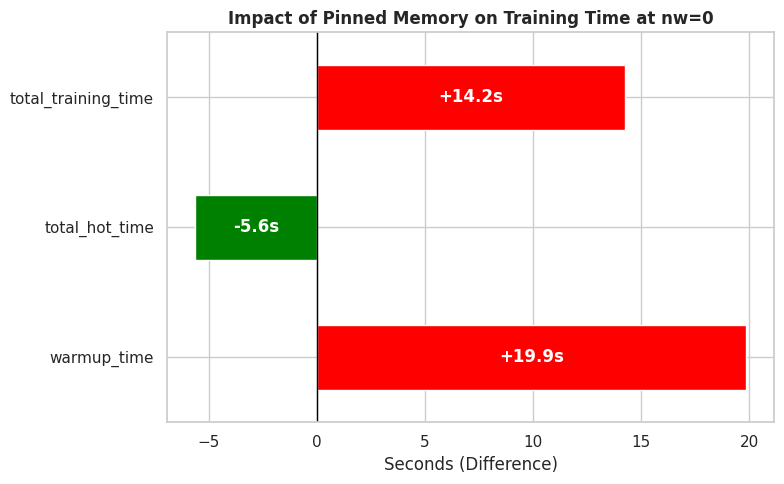

In [18]:
import pandas as pd
import matplotlib.pyplot as plt

# ---------------------------------------------------------
# 1. Recreating your new DataFrame (for testing purposes)
# ---------------------------------------------------------

df = pd.DataFrame(data)

# ---------------------------------------------------------
# 2. Data Preparation using the 'pin_memory' column
# ---------------------------------------------------------
time_cols = ['warmup_time', 'total_hot_time', 'total_training_time']

# Filter the dataframe by the pin_memory flag and extract the time columns as Series
pin_true_times = df[df['pin_memory'] == True][time_cols].iloc[0]
pin_false_times = df[df['pin_memory'] == False][time_cols].iloc[0]

# Calculate the difference (pinTrue - pinFalse)
time_deltas = pin_true_times - pin_false_times

# ---------------------------------------------------------
# 3. Plotting the Diverging Bar Chart
# ---------------------------------------------------------
fig, ax = plt.subplots(figsize=(8, 5))

# Color code: Red for time added (bad), Green for time saved (good)
colors = ['red' if x > 0 else 'green' for x in time_deltas] 

time_deltas.plot(kind='barh', color=colors, ax=ax)
ax.set_title('Impact of Pinned Memory on Training Time at nw=0', fontweight='bold')
ax.set_xlabel('Seconds (Difference)')
ax.axvline(0, color='black', linewidth=1)

# Add text labels centered inside the bars
for i, v in enumerate(time_deltas):
    # Position x in the middle of the bar (v / 2)
    ax.text(v / 2, i, f"{v:+.1f}s", color='white', 
            va='center', ha='center', fontweight='bold')

plt.tight_layout()
plt.show()

In [ ]:
average_hot_time = comparison_df['total_hot_time'].tolist()
average_hot_time = [x / 10 for x in average_hot_time]

[289.6853311061859, 284.0505952835083, 208.09681916236875, 203.88376450538635]

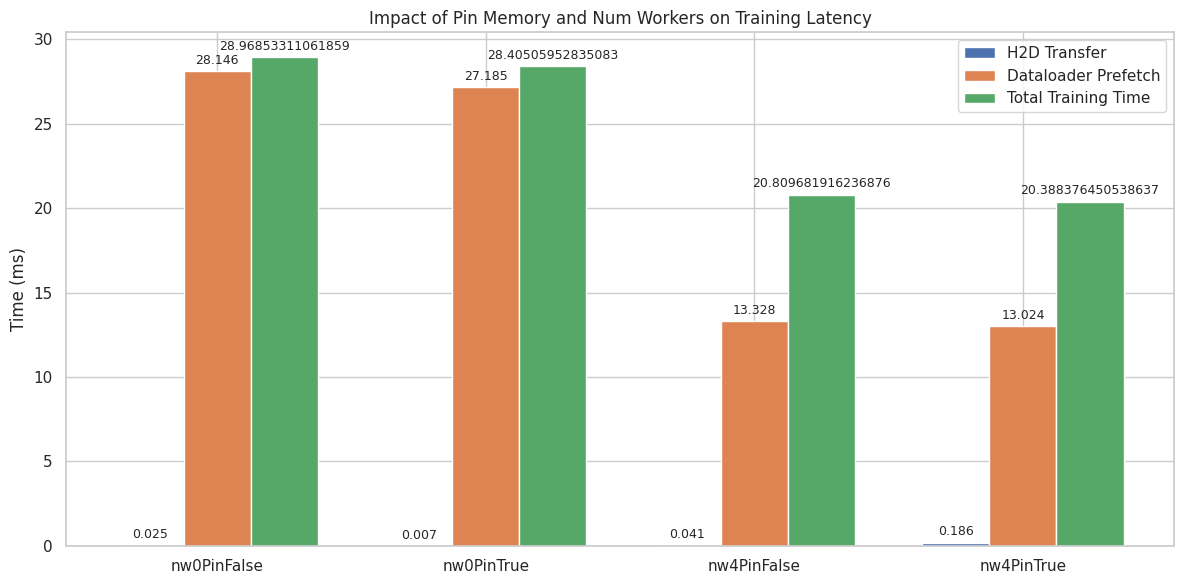

In [31]:
import matplotlib.pyplot as plt
import numpy as np

# 1. Hardcoded Data
experiments = ['nw0PinFalse', 'nw0PinTrue', 'nw4PinFalse', 'nw4PinTrue']

# Metrics (Mock values in milliseconds to illustrate the concept)
average_hot_time = comparison_df['total_hot_time'].tolist()
average_hot_time = [x / 10 for x in average_hot_time]  # Scale down for better visualization
h2d_transfer = [.025, .007, .041, .186]      # Halves with PinTrue
prefetch_time = [28.146, 27.185, 13.328, 13.024] # High for nw0, low for nw4
# total_hot_time = [155.0, 148.0, 65.5, 58.0] # Total loop time

# 2. Setup the Plot
x = np.arange(len(experiments))  # Label locations
width = 0.25  # Width of each individual bar

fig, ax = plt.subplots(figsize=(12, 6))

# 3. Create the Groups
rects1 = ax.bar(x - width, h2d_transfer, width, label='H2D Transfer')
rects2 = ax.bar(x, prefetch_time, width, label='Dataloader Prefetch')
rects3 = ax.bar(x + width, average_hot_time, width, label='Total Training Time')

# 4. Styling and Labels
ax.set_ylabel('Time (ms)')
ax.set_title('Impact of Pin Memory and Num Workers on Training Latency')
ax.set_xticks(x)
ax.set_xticklabels(experiments)
ax.legend()

# Optional: Add text labels on top of the bars
def add_labels(rects):
    for rect in rects:
        height = rect.get_height()
        ax.annotate(f'{height}',
                    xy=(rect.get_x() + rect.get_width() / 2, height),
                    xytext=(0, 3), 
                    textcoords="offset points",
                    ha='center', va='bottom', fontsize=9)

add_labels(rects1)
add_labels(rects2)
add_labels(rects3)

plt.tight_layout()
plt.savefig('dataloader_performance.png')

In [35]:
average_hot_time

[28.96853311061859, 28.40505952835083, 20.809681916236876, 20.388376450538637]

In [39]:
total_hot_time = comparison_df['total_hot_time'].tolist()
average_hot_time = [x / 10 for x in total_hot_time] # uses 10 hot iterations for all exp.
average_hot_time

[28.96853311061859, 28.40505952835083, 20.809681916236876, 20.388376450538637]

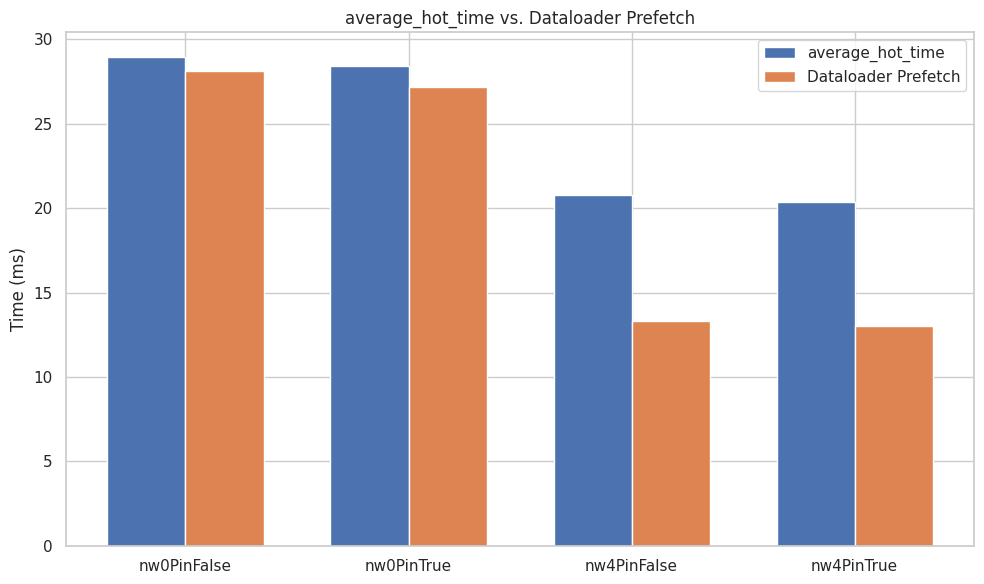

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Data
labels = ['nw0PinFalse', 'nw0PinTrue', 'nw4PinFalse', 'nw4PinTrue']
total_hot_time = comparison_df['total_hot_time'].tolist()
average_hot_time = [x / 10 for x in total_hot_time] # uses 10 hot iterations for all exp.
prefetch_time = [28.146, 27.185, 13.328, 13.024] # 
# h2d_transfer = [.025, .007, .041, .019]      # Halves with PinTrue

x = np.arange(len(labels))
width = 0.35

fig, ax = plt.subplots(figsize=(10, 6))

# Plotting
ax.bar(x - width/2, average_hot_time, width, label='average_hot_time')
ax.bar(x + width/2, prefetch_time, width, label='Dataloader Prefetch')

# Customization
ax.set_ylabel('Time (ms)')
ax.set_title('average_hot_time vs. Dataloader Prefetch')
ax.set_xticks(x)
ax.set_xticklabels(labels)
ax.legend()

plt.tight_layout()
plt.show()

# Analyze Num Workers (nw)

In [8]:
import wandb
import pandas as pd
import matplotlib.pyplot as plt 

# 1. Initialize API and set parameters
api = wandb.Api()
project_path = "as7629-columbia-university/Multimodal-Nanochat"

# Replace these with the actual names of the runs you want to compare
target_run_names = [
    "online_w0_persistFalse_pinTrue_profileFalse", 
    "online_w2_persistFalse_pinTrue_profileFalse",
    "online_w4_persistFalse_pinTrue_profileFalse",
    "online_w8_persistFalse_pinTrue_profileFalse"
] 

# Define which summary metrics you want to pull down
metrics_to_compare = [
    "warmup_time", 
    "total_hot_time", 
    "total_training_time",
    "avg_hot_mfu", 
    "avg_hot_tok_per_sec"
]

data = []

# 2. Fetch and extract data for each run
for name in target_run_names:
    runs = api.runs(project_path, filters={"display_name": name})
    
    if len(runs) == 0:
        print(f"Warning: No run found with name '{name}'")
        continue
        
    run = runs[0]
    
    # Build a dictionary of the run's metadata
    run_data = {
        "Run Name": run.name,
        "Run ID": run.id,
        "State": run.state
    }
    
    # --- NEW: Extract Configuration Parameters ---
    # We use .get() just like we do with summary metrics to prevent crashes 
    # if the config key is missing in an older run
    run_data["pin_memory"] = run.config.get("pin_memory", None)
    run_data["num_workers"] = run.config.get("num_workers", None)
    
    # Extract the summary metrics
    for metric in metrics_to_compare:
        run_data[metric] = run.summary.get(metric, None)
        
    data.append(run_data)

# 3. Create a DataFrame for clean visualization
df = pd.DataFrame(data)


# Print the final comparison table
print("--- Run Comparison ---")
print(df.to_string(index=False))

--- Run Comparison ---
                                   Run Name   Run ID    State  pin_memory  num_workers  warmup_time  total_hot_time  total_training_time  avg_hot_mfu  avg_hot_tok_per_sec
online_w0_persistFalse_pinTrue_profileFalse 1iqksz8s finished        True            0   595.727081      284.050595           879.777676     2.851540          1139.636364
online_w2_persistFalse_pinTrue_profileFalse mxeabn79 finished        True            2   463.748875      260.759001           724.507876     3.229349          1290.818182
online_w4_persistFalse_pinTrue_profileFalse 7d9ffgnq finished        True            4   461.348282      208.096819           669.445101     3.934686          1573.000000
online_w8_persistFalse_pinTrue_profileFalse uqrjx70l finished        True            8   409.592371      204.732246           614.324617     4.012126          1604.000000


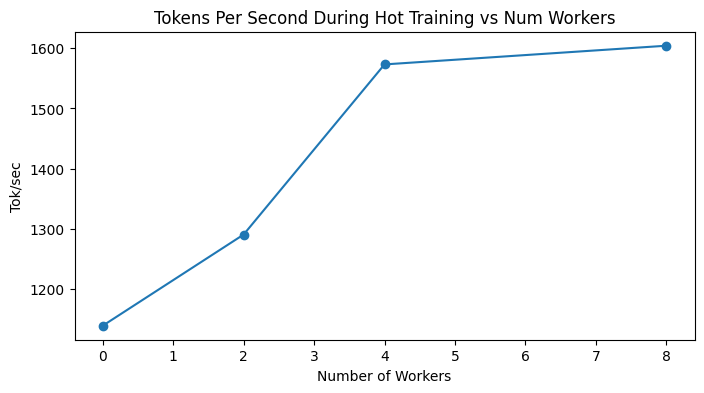

In [9]:
df = df.sort_values('num_workers')

# 1. Line Plot (To see trends/scaling)
plt.figure(figsize=(8, 4))
plt.plot(df['num_workers'], df['avg_hot_tok_per_sec'], marker='o', linestyle='-')
plt.title('Tokens Per Second During Hot Training vs Num Workers')
plt.xlabel('Number of Workers')
plt.ylabel('Tok/sec')
plt.show()

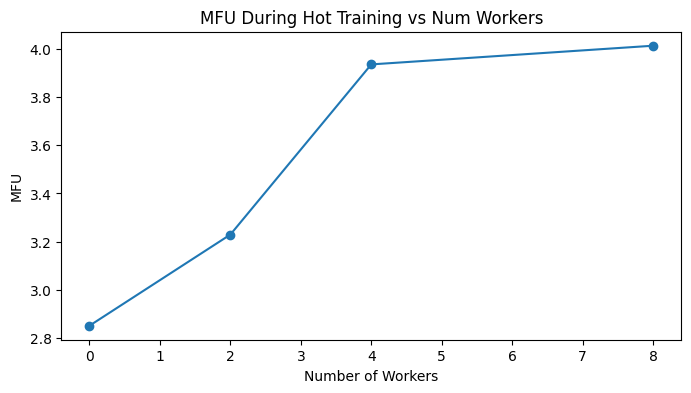

In [10]:
df = df.sort_values('num_workers')

# 1. Line Plot (To see trends/scaling)
plt.figure(figsize=(8, 4))
plt.plot(df['num_workers'], df['avg_hot_mfu'], marker='o', linestyle='-')
plt.title('MFU During Hot Training vs Num Workers')
plt.xlabel('Number of Workers')
plt.ylabel('MFU')
plt.show()

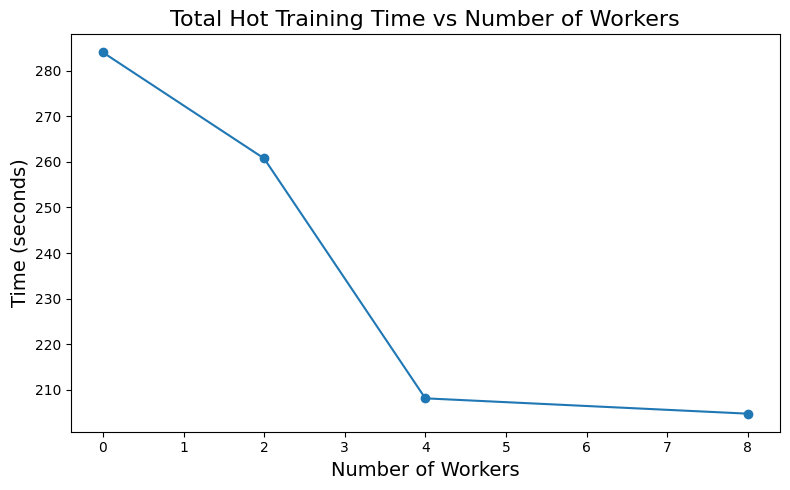

In [14]:
import matplotlib.pyplot as plt

# Assuming your DataFrame 'df' has columns: 'num_workers', 'warmup_time', 'total_hot_time', 'total_training_time'

plt.figure(figsize=(8, 5))

# Plot the three lines
# plt.plot(df['num_workers'], df['warmup_time'], marker='o', label='Warmup Time')
plt.plot(df['num_workers'], df['total_hot_time'], marker='o', label='Total Hot Time')
# plt.plot(df['num_workers'], df['total_training_time'], marker='o', label='Total Training Time')

# Add labels and legend
plt.title('Total Hot Training Time vs Number of Workers', fontsize=16)
plt.xlabel('Number of Workers', fontsize=14)
plt.ylabel('Time (seconds)', fontsize=14)

plt.tight_layout()
plt.show()

# Analyzing Persistent Workers

In [53]:
import wandb
import pandas as pd

# 1. Initialize API and set parameters
api = wandb.Api()
project_path = "as7629-columbia-university/Multimodal-Nanochat"

# Replace these with the actual names of the runs you want to compare
target_run_names = [
    "baseline_online_w4_persistTrue_pinTrue_profileFalse", 
    "baseline_online_w4_persistFalse_pinTrue_profileFalse"
] 

# Define which summary metrics you want to pull down
metrics_to_compare = [
    "warmup_time", 
    "total_hot_time", 
    "total_training_time",
    "avg_hot_mfu", 
    "avg_hot_tok_per_sec"
]

data = []

# 2. Fetch and extract data for each run
for name in target_run_names:
    runs = api.runs(project_path, filters={"display_name": name})
    
    if len(runs) == 0:
        print(f"Warning: No run found with name '{name}'")
        continue
        
    run = runs[0]
    
    # Build a dictionary of the run's metadata
    run_data = {
        "Run Name": run.name,
        "Run ID": run.id,
        "State": run.state
    }
    
    # --- NEW: Extract Configuration Parameters ---
    # We use .get() just like we do with summary metrics to prevent crashes 
    # if the config key is missing in an older run
    run_data["persistent_workers"] = run.config.get("persistent_workers", None)
    
    # Extract the summary metrics
    for metric in metrics_to_compare:
        run_data[metric] = run.summary.get(metric, None)
        
    data.append(run_data)

# 3. Create a DataFrame for clean visualization
comparison_df = pd.DataFrame(data)

# Print the final comparison table
print("--- Run Comparison ---")
print(comparison_df.to_string(index=False))

--- Run Comparison ---
                                            Run Name   Run ID    State  persistent_workers  warmup_time  total_hot_time  total_training_time  avg_hot_mfu  avg_hot_tok_per_sec
 baseline_online_w4_persistTrue_pinTrue_profileFalse g1t0aqvq finished                True   424.078510      214.336245           638.414755     3.795633          1517.363636
baseline_online_w4_persistFalse_pinTrue_profileFalse 7d9ffgnq finished               False   461.348282      208.096819           669.445101     3.934686          1573.000000


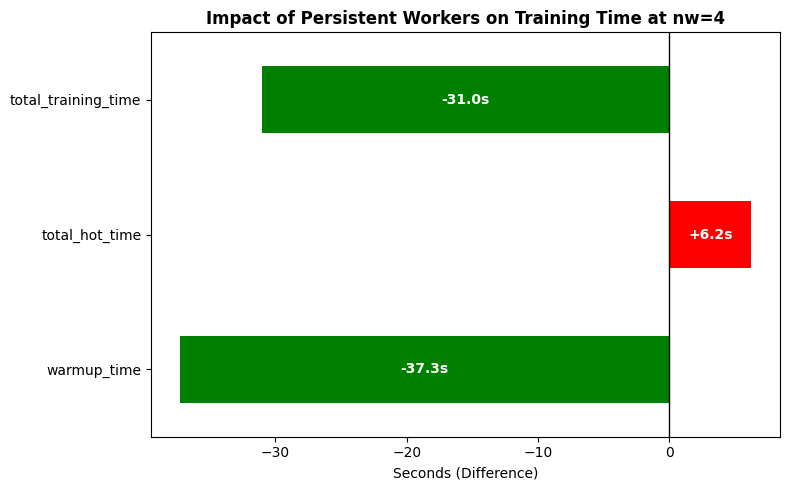

In [56]:
import pandas as pd
import matplotlib.pyplot as plt

# ---------------------------------------------------------
# 1. Recreating your new DataFrame (for testing purposes)
# ---------------------------------------------------------

df = pd.DataFrame(data)

# ---------------------------------------------------------
# 2. Data Preparation using the 'pin_memory' column
# ---------------------------------------------------------
time_cols = ['warmup_time', 'total_hot_time', 'total_training_time']

# Filter the dataframe by the pin_memory flag and extract the time columns as Series
pin_true_times = df[df['persistent_workers'] == True][time_cols].iloc[0]
pin_false_times = df[df['persistent_workers'] == False][time_cols].iloc[0]

# Calculate the difference (pinTrue - pinFalse)
time_deltas = pin_true_times - pin_false_times

# ---------------------------------------------------------
# 3. Plotting the Diverging Bar Chart
# ---------------------------------------------------------
fig, ax = plt.subplots(figsize=(8, 5))

# Color code: Red for time added (bad), Green for time saved (good)
colors = ['red' if x > 0 else 'green' for x in time_deltas] 

time_deltas.plot(kind='barh', color=colors, ax=ax)
ax.set_title('Impact of Persistent Workers on Training Time at nw=4', fontweight='bold')
ax.set_xlabel('Seconds (Difference)')
ax.axvline(0, color='black', linewidth=1)

# Add text labels centered inside the bars
for i, v in enumerate(time_deltas):
    # Position x in the middle of the bar (v / 2)
    ax.text(v / 2, i, f"{v:+.1f}s", color='white', 
            va='center', ha='center', fontweight='bold')

plt.tight_layout()
plt.show()

# Compare offline vs online image embeddings

In [62]:
import wandb
import pandas as pd

# 1. Initialize API and set parameters
api = wandb.Api()
project_path = "as7629-columbia-university/Multimodal-Nanochat"

# Replace these with the actual names of the runs you want to compare
target_run_names = [
    "baseline_online_w4_persistFalse_pinTrue_profileFalse",  # best online setting
    "baseline_offline_pinTrue_profileFalse"
] 

# Define which summary metrics you want to pull down
metrics_to_compare = [
    "warmup_time", 
    "total_hot_time", 
    "total_training_time",
    "avg_hot_mfu", 
    "avg_hot_tok_per_sec"
]

data = []

# 2. Fetch and extract data for each run
for name in target_run_names:
    runs = api.runs(project_path, filters={"display_name": name})
    
    if len(runs) == 0:
        print(f"Warning: No run found with name '{name}'")
        continue
        
    run = runs[0]
    
    # Build a dictionary of the run's metadata
    run_data = {
        "Run Name": run.name,
        "Run ID": run.id,
        "State": run.state
    }
    
    # --- NEW: Extract Configuration Parameters ---
    # We use .get() just like we do with summary metrics to prevent crashes 
    # if the config key is missing in an older run
    run_data["compute_embeddings"] = run.config.get("compute_embeddings", None)
    
    # Extract the summary metrics
    for metric in metrics_to_compare:
        run_data[metric] = run.summary.get(metric, None)
        
    data.append(run_data)

# 3. Create a DataFrame for clean visualization
df = pd.DataFrame(data)

# Print the final comparison table
print("--- Run Comparison ---")
print(comparison_df.to_string(index=False))

--- Run Comparison ---
                                            Run Name   Run ID    State  compute_embeddings  warmup_time  total_hot_time  total_training_time  avg_hot_mfu  avg_hot_tok_per_sec
baseline_online_w4_persistFalse_pinTrue_profileFalse 7d9ffgnq finished                True   461.348282      208.096819           669.445101     3.934686          1573.000000
               baseline_offline_pinTrue_profileFalse hx9jqg2u finished               False    65.623419       33.024591            98.648010    24.799295          9916.545455


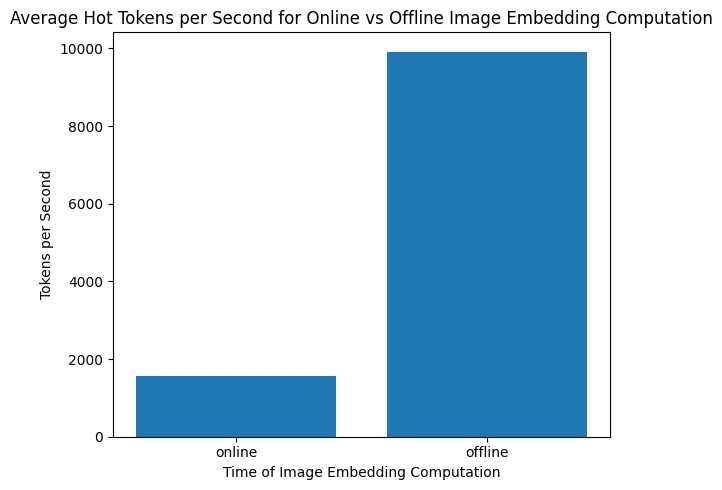

In [67]:
# 1. Extract values for MFU based on the compute_embeddings flag
compute_embeddings_true_mfu = df[df['compute_embeddings'] == True]['avg_hot_tok_per_sec'].iloc[0]
compute_embeddings_false_mfu = df[df['compute_embeddings'] == False]['avg_hot_tok_per_sec'].iloc[0]

# 2. Create simple lists for the x-axis and y-axis
labels = ['online', 'offline']
mfu_values = [compute_embeddings_true_mfu, compute_embeddings_false_mfu]

# 3. Create the single plot
plt.figure(figsize=(6, 5))
plt.bar(labels, mfu_values)

# 4. Add labels and limits
plt.title('Average Hot Tokens per Second for Online vs Offline Image Embedding Computation')
plt.ylabel('Tokens per Second')
plt.xlabel("Time of Image Embedding Computation")

plt.tight_layout()
plt.show()

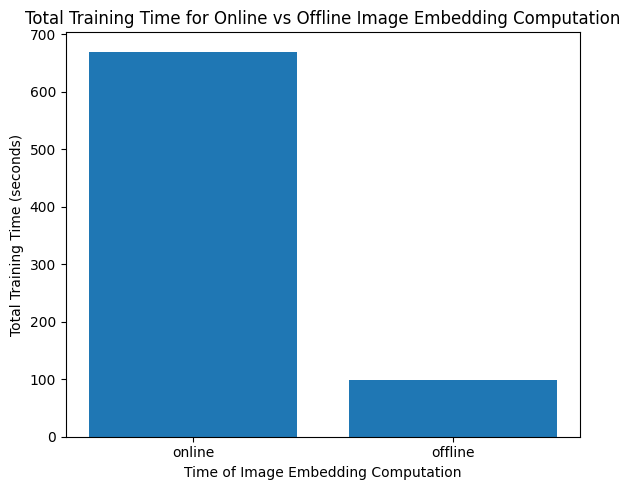

In [70]:
# 1. Extract values for MFU based on the compute_embeddings flag
compute_embeddings_true_mfu = df[df['compute_embeddings'] == True]['total_training_time'].iloc[0]
compute_embeddings_false_mfu = df[df['compute_embeddings'] == False]['total_training_time'].iloc[0]

# 2. Create simple lists for the x-axis and y-axis
labels = ['online', 'offline']
mfu_values = [compute_embeddings_true_mfu, compute_embeddings_false_mfu]

# 3. Create the single plot
plt.figure(figsize=(6, 5))
plt.bar(labels, mfu_values)

# 4. Add labels and limits
plt.title('Total Training Time for Online vs Offline Image Embedding Computation')
plt.ylabel('Total Training Time (seconds)')
plt.xlabel("Time of Image Embedding Computation")

plt.tight_layout()
plt.show()

In [74]:
import wandb
import pandas as pd

# 1. Initialize API and set parameters
api = wandb.Api()
project_path = "as7629-columbia-university/Multimodal-Nanochat"

# Replace these with the actual names of the runs you want to compare
target_run_names = [
    "baseline_offline_pinFalse_profileFalse", 
    "baseline_offline_pinTrue_profileFalse"
] 

# Define which summary metrics you want to pull down
metrics_to_compare = [
    "warmup_time", 
    "total_hot_time", 
    "total_training_time",
    "avg_hot_tok_per_sec"
]

data = []

# 2. Fetch and extract data for each run
for name in target_run_names:
    runs = api.runs(project_path, filters={"display_name": name})
    
    if len(runs) == 0:
        print(f"Warning: No run found with name '{name}'")
        continue
        
    run = runs[0]
    
    # Build a dictionary of the run's metadata
    run_data = {
        "Run Name": run.name,
        "Run ID": run.id,
        "State": run.state
    }
    
    # --- NEW: Extract Configuration Parameters ---
    # We use .get() just like we do with summary metrics to prevent crashes 
    # if the config key is missing in an older run
    run_data["pin_memory"] = run.config.get("pin_memory", None)
    
    # Extract the summary metrics
    for metric in metrics_to_compare:
        run_data[metric] = run.summary.get(metric, None)
        
    data.append(run_data)

# 3. Create a DataFrame for clean visualization
comparison_df = pd.DataFrame(data)
df = comparison_df
# Print the final comparison table
print("--- Run Comparison ---")
print(comparison_df.to_string(index=False))

--- Run Comparison ---
                              Run Name   Run ID    State  pin_memory  warmup_time  total_hot_time  total_training_time  avg_hot_tok_per_sec
baseline_offline_pinFalse_profileFalse tzqkgfas finished       False    66.006925       33.214717            99.221642          9858.909091
 baseline_offline_pinTrue_profileFalse hx9jqg2u finished        True    65.623419       33.024591            98.648010          9916.545455


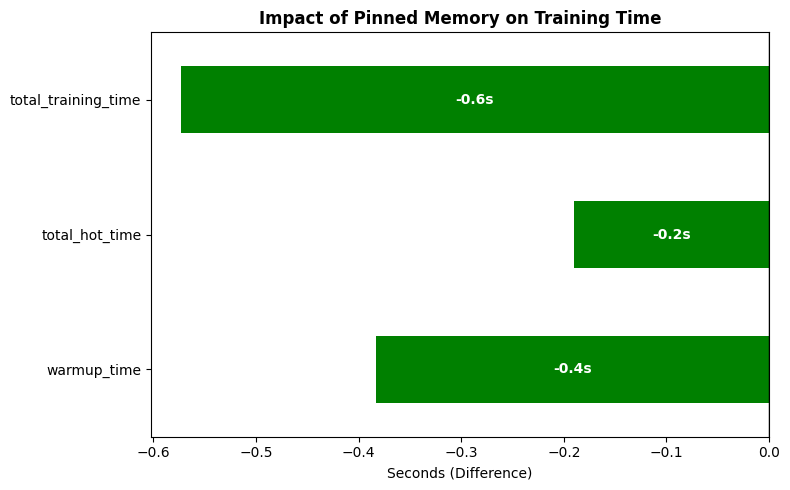

In [76]:
df = pd.DataFrame(data)

# ---------------------------------------------------------
# 2. Data Preparation using the 'pin_memory' column
# ---------------------------------------------------------
time_cols = ['warmup_time', 'total_hot_time', 'total_training_time']

# Filter the dataframe by the pin_memory flag and extract the time columns as Series
pin_true_times = df[df['pin_memory'] == True][time_cols].iloc[0]
pin_false_times = df[df['pin_memory'] == False][time_cols].iloc[0]

# Calculate the difference (pinTrue - pinFalse)
time_deltas = pin_true_times - pin_false_times

# ---------------------------------------------------------
# 3. Plotting the Diverging Bar Chart
# ---------------------------------------------------------
fig, ax = plt.subplots(figsize=(8, 5))

# Color code: Red for time added (bad), Green for time saved (good)
colors = ['red' if x > 0 else 'green' for x in time_deltas] 

time_deltas.plot(kind='barh', color=colors, ax=ax)
ax.set_title('Impact of Pinned Memory on Training Time', fontweight='bold')
ax.set_xlabel('Seconds (Difference)')
ax.axvline(0, color='black', linewidth=1)

# Add text labels centered inside the bars
for i, v in enumerate(time_deltas):
    # Position x in the middle of the bar (v / 2)
    ax.text(v / 2, i, f"{v:+.1f}s", color='white', 
            va='center', ha='center', fontweight='bold')

plt.tight_layout()
plt.show()

# AMP

In [ ]:
import wandb
import pandas as pd

# 1. Initialize API and set parameters
api = wandb.Api()
project_path = "as7629-columbia-university/Multimodal-Nanochat"

# Replace these with the actual names of the runs you want to compare
target_run_names = [
    "baseline_online_w4_persistFalse_pinTrue_profileFalse", 
    "baseline_online_w4_persistFalse_pinFalse_profileFalse"
] 

# Define which summary metrics you want to pull down
metrics_to_compare = [
    "warmup_time", 
    "total_hot_time", 
    "total_training_time",
    "avg_hot_mfu", 
    "avg_hot_tok_per_sec"
]

data = []

# 2. Fetch and extract data for each run
for name in target_run_names:
    runs = api.runs(project_path, filters={"display_name": name})
    
    if len(runs) == 0:
        print(f"Warning: No run found with name '{name}'")
        continue
        
    run = runs[0]
    
    # Build a dictionary of the run's metadata
    run_data = {
        "Run Name": run.name,
        "Run ID": run.id,
        "State": run.state
    }
    
    # --- NEW: Extract Configuration Parameters ---
    # We use .get() just like we do with summary metrics to prevent crashes 
    # if the config key is missing in an older run
    run_data["pin_memory"] = run.config.get("pin_memory", None)
    
    # Extract the summary metrics
    for metric in metrics_to_compare:
        run_data[metric] = run.summary.get(metric, None)
        
    data.append(run_data)

# 3. Create a DataFrame for clean visualization
comparison_df = pd.DataFrame(data)

# Print the final comparison table
print("--- Run Comparison ---")
print(comparison_df.to_string(index=False))

# Presentation Plots: Baseline vs Optimized

In [9]:
import wandb
import pandas as pd

# 1. Initialize API
api = wandb.Api()
project_path = "as7629-columbia-university/Multimodal-Nanochat"

# Mapping specific runs to the metrics they provide
# Key: The descriptive name for our script | Value: The exact wandb display name
run_map = {
    "base_train": "baseline_online_w0_persistFalse_pinFalse_profileFalse",
    "base_infer": "baseline_evalBS1_KVCacheFalse",
    "opt_train":  "optimized_offline_pinTrue_profileFalse",
    "opt_infer":  "optimized_evalBS16_KVCacheFalse"
}

# Helper function to fetch a single run by name
def get_run_summary(display_name):
    runs = api.runs(project_path, filters={"display_name": display_name})
    if len(runs) == 0:
        print(f"Warning: No run found with name '{display_name}'")
        return None
    return runs[0].summary

# 2. Fetch the data from W&B
summaries = {key: get_run_summary(name) for key, name in run_map.items()}

# 3. Extract specific values 
# Replace the strings in .get() with the actual keys used in your wandb logging
# e.g., if your code logs 'gpu_utilization', change 'GPU Util (%)' below.
labels = ['Est. SM Utilization (%)', 'Train Time (s)', 'Inference (Tok/Sec)']

# Baseline values
baseline = [
    9.54, # taken from baseline_online_w0_persistFalse_pinFalse_profileTrue
    summaries["base_train"].get("total_hot_time", 0) if summaries["base_train"] else 0,
    summaries["base_infer"].get("val/tok_per_sec", 0) if summaries["base_infer"] else 0,
]

# Optimized values
optimized = [
    92.22, # taken from optimized_offline_pinTrue_profileTrue
    summaries["opt_train"].get("total_hot_time", 0) if summaries["opt_train"] else 0,
    summaries["opt_infer"].get("val/tok_per_sec", 0) if summaries["opt_infer"] else 0,
    
]

# 4. Final Output/Verification
print("Labels:   ", labels)
print("Baseline: ", baseline)
print("Optimized:", optimized)


Labels:    ['Est. SM Utilization (%)', 'Train Time (s)', 'Inference (Tok/Sec)']
Baseline:  [9.54, 289.6853311061859, 34.308440490703624]
Optimized: [92.22, 33.02459120750427, 197.0843000900446]


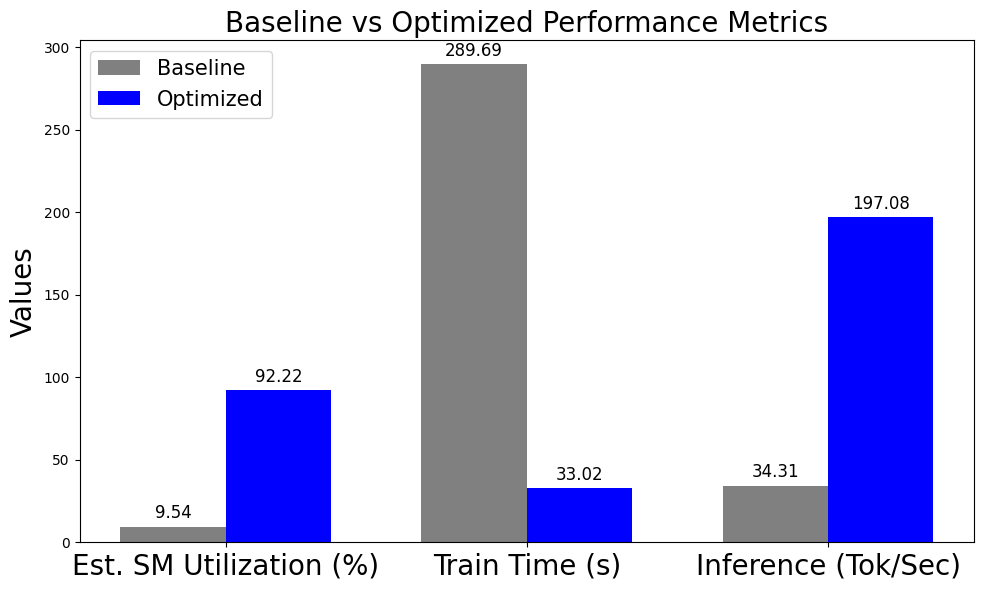

In [10]:
import matplotlib.pyplot as plt
import numpy as np

# Data
# baseline GPU Util and Train time come from online_w0_persistFalse_pinFalse_profileFalse
# baseline Inference comes from evalBS1_KVCacheFalse
# optimized GPU Util and Train time come from offline_pinFalse_profileFalse
# # optimized Inference comes from evalBS16_KVCacheFalse
# labels = ['Est. SM Efficiency (%)', 'Inference (Tok/Sec)', 'Train Time (s)']
# baseline = [14.23, 34.30844, 613.45698]
# optimized = [92.22, 197.0843, 99.74508]

# Set up the bar locations and width
x = np.arange(len(labels))
width = 0.35

fig, ax = plt.subplots(figsize=(10, 6))

# Plot the bars
rects1 = ax.bar(x - width/2, baseline, width, label='Baseline', color='grey')
rects2 = ax.bar(x + width/2, optimized, width, label='Optimized', color='blue')

# Formatting and labels
ax.set_ylabel('Values', size=20)
ax.set_title('Baseline vs Optimized Performance Metrics', size=20)
ax.set_xticks(x)
ax.set_xticklabels(labels, size=20)
ax.legend(title="", fontsize=15, loc='upper left')

# Add text labels on top of the bars, rounded to 2 decimal places
ax.bar_label(rects1, padding=3, fmt='%.2f', size=12)
ax.bar_label(rects2, padding=3, fmt='%.2f', size=12)

fig.tight_layout()

# Save the figure
plt.savefig('performance_comparison.png')

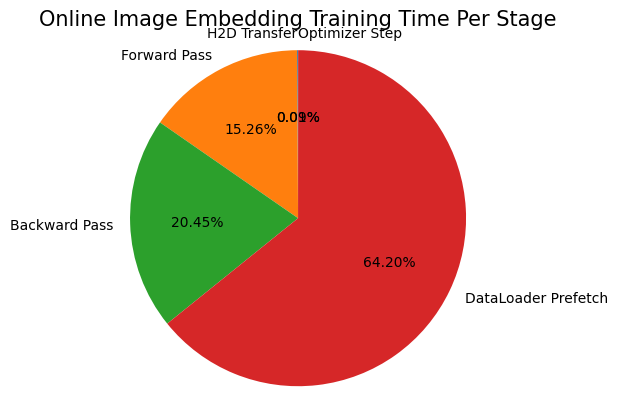

In [ ]:
# from run baseline_online_w4_persistFalse_pinTrue_profileTrue
import matplotlib.pyplot as plt

# 1. Define your data
labels = ['H2D Transfer', 'Forward Pass', 'Backward Pass', 'DataLoader Prefetch', "Optimizer Step"]
sizes = [18.581 , 3095.662 , 4148.218 , 13024.378, 1.083] # These represent the values or percentages for each slice

# 2. Create the pie chart
fig, ax = plt.subplots()
ax.pie(
    sizes, 
    labels=labels, 
    autopct='%1.2f%%', # Automatically formats the values as percentages
    startangle=90      # Rotates the start of the pie chart by 90 degrees
)

# 3. Ensure the pie chart is drawn as a perfect circle
ax.axis('equal')  

# 4. Display or save the chart
plt.title("Online Image Embedding Training Time Per Stage", size=15)
plt.show() 
# Or save it to a file using: plt.savefig('my_pie_chart.png')

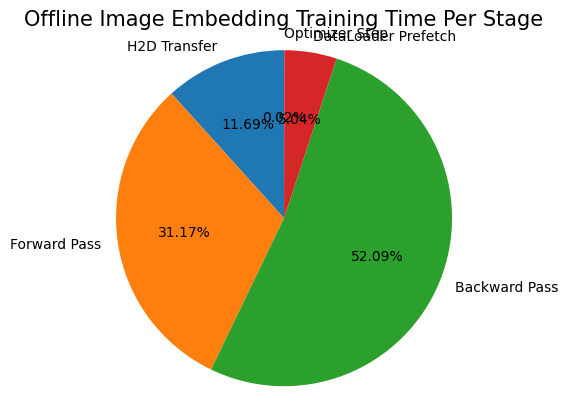

In [ ]:
# from run baseline_offline_pinTrue_profileTrue
# 1. Define your data
labels = ['H2D Transfer', 'Forward Pass', 'Backward Pass', 'DataLoader Prefetch', "Optimizer Step"]
sizes = [396.269  , 1056.882 , 1766.371  , 170.897 , 0.685] # These represent the values or percentages for each slice

# 2. Create the pie chart
fig, ax = plt.subplots()
ax.pie(
    sizes, 
    labels=labels, 
    autopct='%1.2f%%', # Automatically formats the values as percentages
    startangle=90      # Rotates the start of the pie chart by 90 degrees
)

# 3. Ensure the pie chart is drawn as a perfect circle
ax.axis('equal')  

# 4. Display or save the chart
plt.title("Offline Image Embedding Training Time Per Stage", size=15)
plt.show() 
# Or save it to a file using: plt.savefig('my_pie_chart.png')

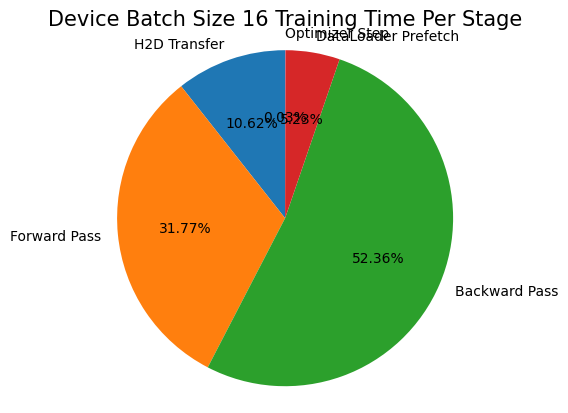

In [8]:
# from run baseline_deviceBS16_bfloat16_profileFalse
# 1. Define your data
labels = ['H2D Transfer', 'Forward Pass', 'Backward Pass', 'DataLoader Prefetch', "Optimizer Step"]
sizes = [358.553  , 1072.616  , 1767.721   , 176.555  , 0.870 ] # These represent the values or percentages for each slice

# 2. Create the pie chart
fig, ax = plt.subplots()
ax.pie(
    sizes, 
    labels=labels, 
    autopct='%1.2f%%', # Automatically formats the values as percentages
    startangle=90      # Rotates the start of the pie chart by 90 degrees
)

# 3. Ensure the pie chart is drawn as a perfect circle
ax.axis('equal')  

# 4. Display or save the chart
# plt.title("BF16 Training Time Per Stage", size=15)
plt.title("Device Batch Size 16 Training Time Per Stage", size=15)

plt.show() 
# Or save it to a file using: plt.savefig('my_pie_chart.png')

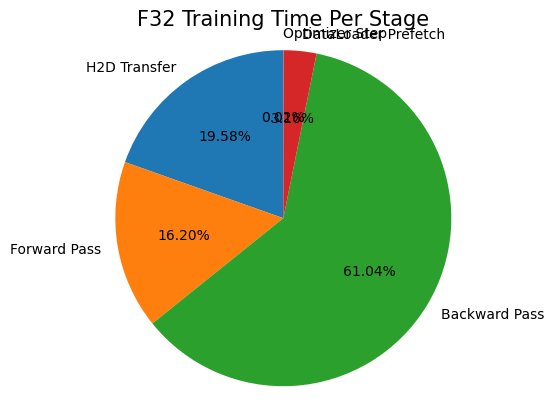

In [96]:
# from run baseline_deviceBS16_bfloat16_profileFalse
# 1. Define your data
labels = ['H2D Transfer', 'Forward Pass', 'Backward Pass', 'DataLoader Prefetch', "Optimizer Step"]
sizes = [982.020   , 812.558   , 3061.317    , 158.476  , 0.842 ] # These represent the values or percentages for each slice

# 2. Create the pie chart
fig, ax = plt.subplots()
ax.pie(
    sizes, 
    labels=labels, 
    autopct='%1.2f%%', # Automatically formats the values as percentages
    startangle=90      # Rotates the start of the pie chart by 90 degrees
)

# 3. Ensure the pie chart is drawn as a perfect circle
ax.axis('equal')  

# 4. Display or save the chart
plt.title("F32 Training Time Per Stage", size=15)
plt.show() 
# Or save it to a file using: plt.savefig('my_pie_chart.png')

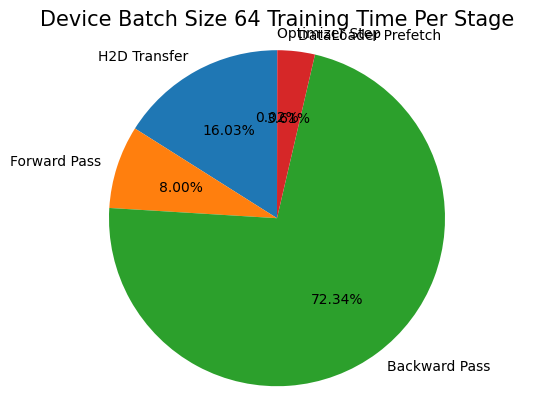

In [9]:
# from run baseline_deviceBS16_bfloat16_profileFalse
# 1. Define your data
labels = ['H2D Transfer', 'Forward Pass', 'Backward Pass', 'DataLoader Prefetch', "Optimizer Step"]
sizes = [662.824   , 330.566   , 2990.558    , 149.341  , 0.792 ] # These represent the values or percentages for each slice

# 2. Create the pie chart
fig, ax = plt.subplots()
ax.pie(
    sizes, 
    labels=labels, 
    autopct='%1.2f%%', # Automatically formats the values as percentages
    startangle=90      # Rotates the start of the pie chart by 90 degrees
)

# 3. Ensure the pie chart is drawn as a perfect circle
ax.axis('equal')  

# 4. Display or save the chart
plt.title("Device Batch Size 64 Training Time Per Stage", size=15)
plt.show() 
# Or save it to a file using: plt.savefig('my_pie_chart.png')

# Tuning Learning Rate

In [23]:
import wandb
import pandas as pd

# 1. Initialize API and set parameters
api = wandb.Api()
project_path = "as7629-columbia-university/Multimodal-Nanochat"

# Replace these with the actual names of the runs you want to compare
target_run_names = [
    "iteration500_totalBS32768_lr1e-1", 
    "optimized_iteration500_totalBS32768_lr1e-2",
    "iteration1000_totalBS32768_lr1e-3", # this run should have been trained for 500 iterations. Since loss and validation scores plateau, this did not affect analysis.
    "iteration500_totalBS32768_lr1e-4"
] 

# Define which summary metrics you want to pull down
metrics_to_compare = [
    "val/bpb",
    "val/avg_semantic_similarity",
    "train/loss",
    "top_avg_semantic_similarity",
    "min_val_bpb"
]

data = []

# 2. Fetch and extract data for each run
for name in target_run_names:
    runs = api.runs(project_path, filters={"display_name": name})
    
    if len(runs) == 0:
        print(f"Warning: No run found with name '{name}'")
        continue
        
    run = runs[0]
    
    # Build a dictionary of the run's metadata
    run_data = {
        "Run Name": run.name,
        "Run ID": run.id,
        "State": run.state
    }
    
    # --- NEW: Extract Configuration Parameters ---
    # We use .get() just like we do with summary metrics to prevent crashes 
    # if the config key is missing in an older run
    run_data["vision_lr"] = run.config.get("vision_lr", None)
    
    
    # Extract the summary metrics
    for metric in metrics_to_compare:
        run_data[metric] = run.summary.get(metric, None)
        
    data.append(run_data)

# 3. Create a DataFrame for clean visualization
df = pd.DataFrame(data)


# Print the final comparison table
print("--- Run Comparison ---")
print(df.to_string(index=False))

--- Run Comparison ---
                                  Run Name   Run ID    State  vision_lr  val/bpb  val/avg_semantic_similarity  train/loss  top_avg_semantic_similarity  min_val_bpb
          iteration500_totalBS32768_lr1e-1 09h81lqy finished     0.1000 0.989723                     0.348698    2.760623                     0.364920     0.989723
optimized_iteration500_totalBS32768_lr1e-2 p79t3b33 finished     0.0100 0.969988                     0.417193    2.669118                     0.417193     0.969988
         iteration1000_totalBS32768_lr1e-3 tywdecvd finished     0.0010 0.959937                     0.384584    2.669711                     0.408364     0.953241
          iteration500_totalBS32768_lr1e-4 a3sr2x9e finished     0.0001 1.016932                     0.300134    2.874715                     0.311100     1.016932


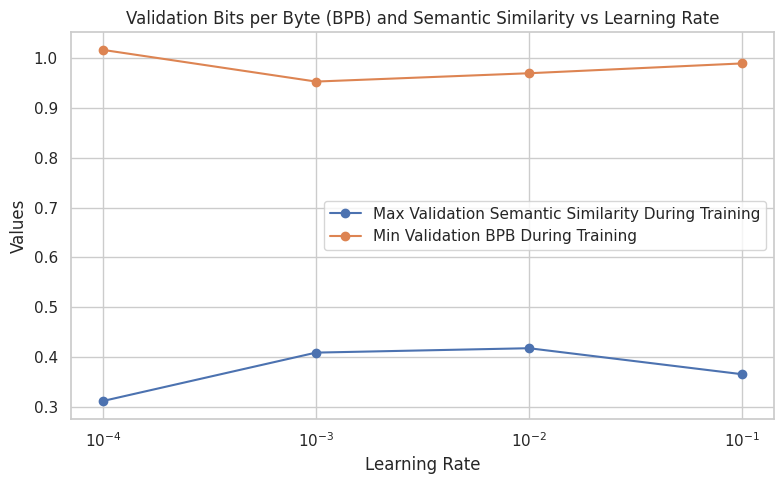

In [27]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))

# Plot the three lines
plt.plot(df['vision_lr'], df['top_avg_semantic_similarity'], marker='o', label='Max Validation Semantic Similarity During Training')
plt.plot(df['vision_lr'], df['min_val_bpb'], marker='o', label='Min Validation BPB During Training')

# Add labels and legend
plt.title('Validation Bits per Byte (BPB) and Semantic Similarity vs Learning Rate')
plt.xlabel('Learning Rate')
plt.xscale('log')
plt.ylabel('Values')
plt.legend()

plt.tight_layout()
plt.show()

# Tuning Total BS

# Device BS

In [12]:
import wandb
import pandas as pd
import matplotlib.pyplot as plt 

# 1. Initialize API and set parameters
api = wandb.Api()
project_path = "as7629-columbia-university/Multimodal-Nanochat"

# Replace these with the actual names of the runs you want to compare
target_run_names = [
    "iteration2000_totalBS8192_lr1e-2", 
    "iteration1000_totalBS16384_lr1e-2",
    "optimized_iteration500_totalBS32768_lr1e-2",
    "iteration250_totalBS65536_lr1e-2"
] 

# Define which summary metrics you want to pull down
metrics_to_compare = [
    "total_hot_time", 
    "avg_hot_tok_per_sec",
    "peak_memory_mib",
    "val/bpb",
    "val/avg_semantic_similarity",
    "top_avg_semantic_similarity"
]

data = []

# 2. Fetch and extract data for each run
for name in target_run_names:
    runs = api.runs(project_path, filters={"display_name": name})
    
    if len(runs) == 0:
        print(f"Warning: No run found with name '{name}'")
        continue
        
    run = runs[0]
    
    # Build a dictionary of the run's metadata
    run_data = {
        "Run Name": run.name,
        "Run ID": run.id,
        "State": run.state
    }
    
    # --- NEW: Extract Configuration Parameters ---
    # We use .get() just like we do with summary metrics to prevent crashes 
    # if the config key is missing in an older run
    run_data["total_batch_size"] = run.config.get("total_batch_size", None)
    
    # Extract the summary metrics
    for metric in metrics_to_compare:
        run_data[metric] = run.summary.get(metric, None)
        
    data.append(run_data)

# 3. Create a DataFrame for clean visualization
df = pd.DataFrame(data)


# Print the final comparison table
print("--- Run Comparison ---")
print(df.to_string(index=False))

--- Run Comparison ---
                                  Run Name   Run ID    State  total_batch_size  total_hot_time avg_hot_tok_per_sec  peak_memory_mib  val/bpb  val/avg_semantic_similarity  top_avg_semantic_similarity
          iteration2000_totalBS8192_lr1e-2 6wjuc9yx finished              8192     1606.096134                None       8244.17041 0.947301                     0.313701                     0.417338
         iteration1000_totalBS16384_lr1e-2 w99q2fpt finished             16384     1583.623952                None       8244.17041 0.952980                     0.375094                     0.395377
optimized_iteration500_totalBS32768_lr1e-2 p79t3b33 finished             32768     1585.541125                None       8244.17041 0.969988                     0.417193                     0.417193
          iteration250_totalBS65536_lr1e-2 9dg51zfq finished             65536     1520.595607                None       8292.57666 0.952394                     0.386469            

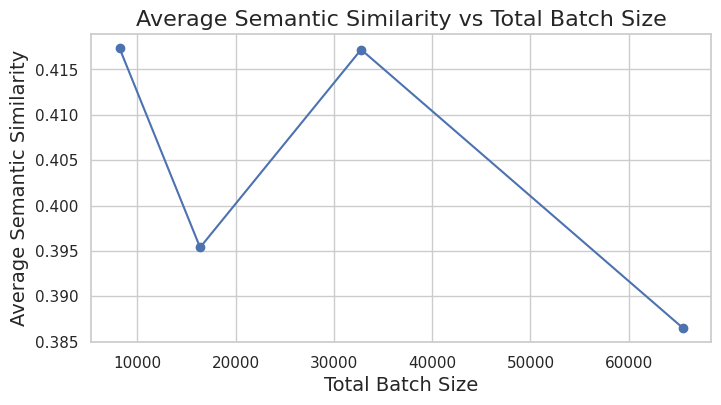

In [13]:
df = df.sort_values('total_batch_size')


# 1. Line Plot (To see trends/scaling)
plt.figure(figsize=(8, 4))
plt.plot(df['total_batch_size'], df['top_avg_semantic_similarity'], marker='o', linestyle='-')
plt.title('Average Semantic Similarity vs Total Batch Size', fontsize=16)
plt.xlabel('Total Batch Size', fontsize=14)
plt.ylabel('Average Semantic Similarity', fontsize=14)
plt.show()

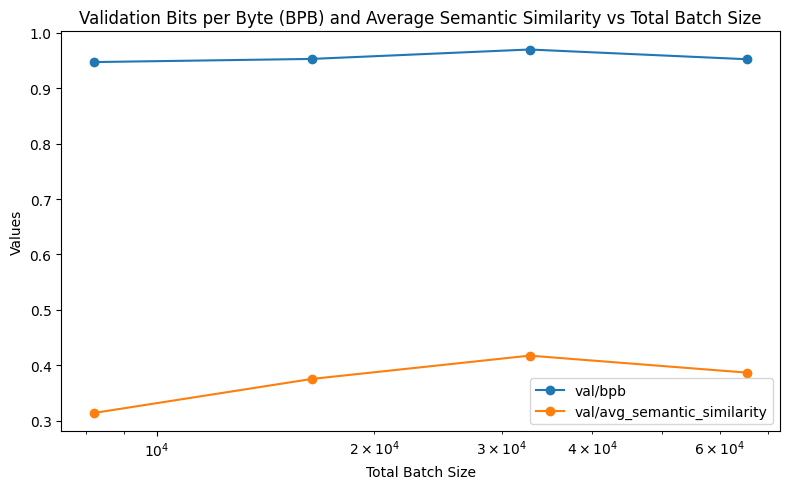

In [6]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))

# Plot the three lines
plt.plot(df['total_batch_size'], df['val/bpb'], marker='o', label='val/bpb')
plt.plot(df['total_batch_size'], df['val/avg_semantic_similarity'], marker='o', label='val/avg_semantic_similarity')
# plt.plot(df['vision_lr'], df['train/loss'], marker='o', label='train/loss')

# Add labels and legend
plt.title('Validation Bits per Byte (BPB) and Average Semantic Similarity vs Total Batch Size')
plt.xlabel('Total Batch Size')
plt.xscale('log')
plt.ylabel('Values')
plt.legend()

plt.tight_layout()
plt.show()

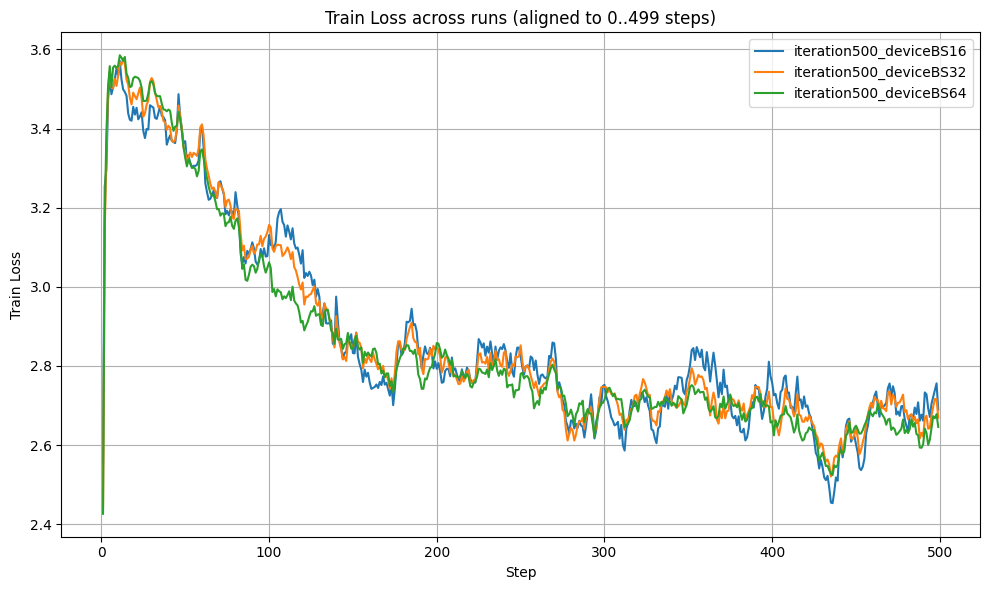

In [8]:
import matplotlib.pyplot as plt

# Ensure loss_df exists from the previous cell
try:
    df_plot = loss_df
except NameError:
    raise RuntimeError("loss_df not found. Run the previous cell to fetch per-step histories.")

plt.figure(figsize=(10, 6))
for col in df_plot.columns:
    plt.plot(df_plot.index, df_plot[col], label=col)

plt.xlabel('Step')
plt.ylabel('Train Loss')
plt.title('Train Loss across runs (aligned to 0..499 steps)')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


# Total BS training interaction

# Total Batch Size Effect on Convergence and Caption Quality

In [7]:
import wandb
import pandas as pd

# 1. Initialize API and set parameters
api = wandb.Api()
project_path = "as7629-columbia-university/Multimodal-Nanochat"

# Replace these with the actual names of the 3 runs you want to extract
target_run_names = [
    "iteration2000_totalBS8192_lr1e-2", 
    "iteration1000_totalBS16384_lr1e-2",
    "iteration500_totalBS32768_lr1e-2",
    
] 

all_history_data = []

# 2. Fetch and extract history data for each run
for name in target_run_names:
    runs = api.runs(project_path, filters={"display_name": name})
    
    if len(runs) == 0:
        print(f"Warning: No run found with name '{name}'")
        continue
        
    run = runs[0]
    print(f"Fetching history for run: {name} (ID: {run.id})")
    
    # --- NEW: Extract History Metrics ---
    # We use run.scan_history() instead of run.history() because .history() 
    # downsamples the data to 500 points by default. scan_history() gets every step.
    # We pull "_step" as a fallback, as W&B logs global steps there by default.
    history_iter = run.scan_history(keys=["step", "_step", "train/loss"])
    
    for row in history_iter:
        # Check if train/loss actually exists at this step to avoid appending empty data 
        # (happens if other metrics were logged at a step without train/loss)
        if "train/loss" in row and row["train/loss"] is not None:
            row_data = {
                "Run Name": name,
                # Try to get the explicit "step", fallback to W&B's internal "_step"
                "step": row.get("step", row.get("_step")), 
                "train/loss": row["train/loss"]
            }
            all_history_data.append(row_data)

# 3. Create a DataFrame for clean visualization and analysis
history_df = pd.DataFrame(all_history_data)

# Print a summary of the extracted data
print("\n--- Run History Data Head ---")
print(history_df.head())
print(f"\nTotal rows extracted: {len(history_df)}")

# (Optional) If you want to pivot the data so each run is a column and step is the index:
# pivoted_df = history_df.pivot(index='step', columns='Run Name', values='train/loss')
# print(pivoted_df.head())

Fetching history for run: iteration2000_totalBS8192_lr1e-2 (ID: 6wjuc9yx)
Fetching history for run: iteration1000_totalBS16384_lr1e-2 (ID: w99q2fpt)

--- Run History Data Head ---
Empty DataFrame
Columns: []
Index: []

Total rows extracted: 0


In [10]:
import wandb
import pandas as pd

# 1. Initialize API and set parameters
api = wandb.Api()
project_path = "as7629-columbia-university/Multimodal-Nanochat"

target_run_names = [
    "iteration2000_totalBS8192_lr1e-2", 
    "iteration1000_totalBS16384_lr1e-2",
    "optimized_iteration500_totalBS32768_lr1e-2",
    "iteration250_totalBS65536_lr1e-2"
] 

all_history_data = []

# 2. Fetch and extract history data for each run
for name in target_run_names:
    runs = api.runs(project_path, filters={"display_name": name})
    
    if len(runs) == 0:
        print(f"Warning: No run found with name '{name}'")
        continue
        
    run = runs[0]
    print(f"\nFetching history for run: {name} (ID: {run.id})")
    
    # --- DIAGNOSTIC CHECK ---
    # Pull a single sample to see exactly what W&B named your columns
    sample_history = run.history(samples=1)
    if not sample_history.empty:
        print(f"Available columns in this run: {sample_history.columns.tolist()}")
    else:
        print("Warning: run.history() is completely empty. No metrics logged.")
        continue

    # --- NEW: Extract History without 'keys' filter ---
    # Removing keys=[...] forces W&B to yield whatever is present at each step.
    # We will manually check for the key inside the loop.
    history_iter = run.scan_history()
    
    # Update this target_metric variable if your diagnostic print above 
    # reveals the loss is actually named something else (e.g., "Loss", "train_loss")
    target_metric = "train/loss"
    
    rows_found = 0
    for row in history_iter:
        # Check if our target metric is in this specific step's data and isn't None
        if target_metric in row and row[target_metric] is not None:
            row_data = {
                "Run Name": name,
                # Try explicit 'step', fallback to W&B internal '_step'
                "step": row.get("step", row.get("_step")), 
                target_metric: row[target_metric]
            }
            all_history_data.append(row_data)
            rows_found += 1
            
    print(f"Found {rows_found} rows containing '{target_metric}'")

# 3. Create a DataFrame
if all_history_data:
    history_df = pd.DataFrame(all_history_data)
    print("\n--- Run History Data Head ---")
    print(history_df.head())
    print(f"\nTotal rows extracted: {len(history_df)}")
else:
    print("\nDataFrame is empty! Check the diagnostic output above to ensure the metric name matches exactly.")


Fetching history for run: iteration2000_totalBS8192_lr1e-2 (ID: 6wjuc9yx)
Available columns in this run: ['_step', 'train/dt', '_runtime', 'train/h2d_transfer_ms', 'train/tok_per_sec', 'train/loss', 'total_training_time', 'train/epoch', 'train/mfu', 'train/dataloader_fraction', 'total_training_flops', '_timestamp', 'train/dataloader_wait_ms']
Found 2000 rows containing 'train/loss'

Fetching history for run: iteration1000_totalBS16384_lr1e-2 (ID: w99q2fpt)
Available columns in this run: ['_step', 'train/dt', '_runtime', 'train/h2d_transfer_ms', 'train/tok_per_sec', 'train/loss', 'total_training_time', 'train/epoch', 'train/mfu', 'train/dataloader_fraction', 'total_training_flops', '_timestamp', 'train/dataloader_wait_ms']
Found 1000 rows containing 'train/loss'

Fetching history for run: optimized_iteration500_totalBS32768_lr1e-2 (ID: p79t3b33)
Available columns in this run: ['_step', 'train/dt', '_runtime', 'train/h2d_transfer_ms', 'train/tok_per_sec', 'train/loss', 'total_training_t

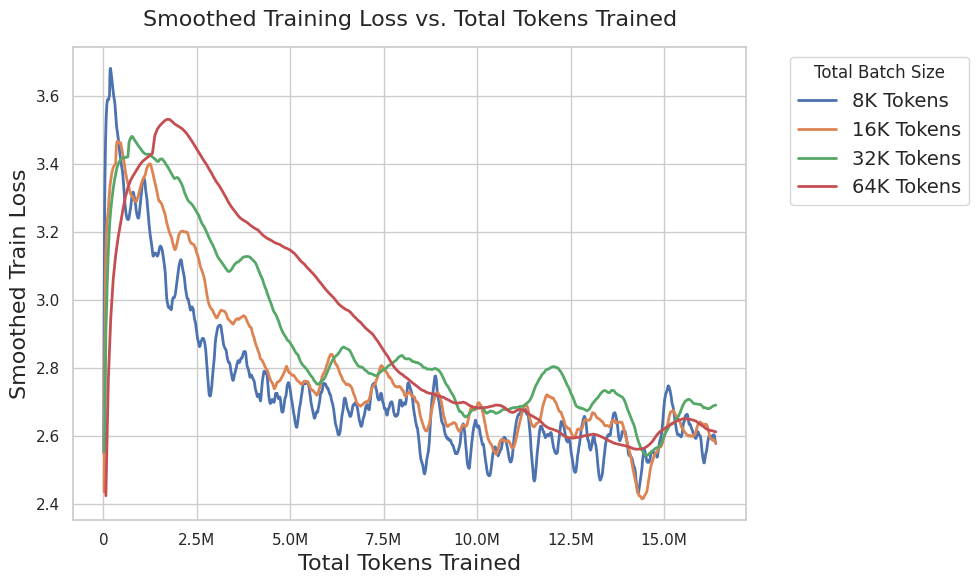

In [11]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Map batch sizes and calculate samples seen
batch_size_mapping = {
    "iteration2000_totalBS8192_lr1e-2": 8192,
    "iteration1000_totalBS16384_lr1e-2": 16384,
    "optimized_iteration500_totalBS32768_lr1e-2": 32768,
    "iteration250_totalBS65536_lr1e-2": 65536
}

custom_labels = {
    "iteration2000_totalBS8192_lr1e-2": "8K Tokens",
    "iteration1000_totalBS16384_lr1e-2": "16K Tokens",
    "optimized_iteration500_totalBS32768_lr1e-2": "32K Tokens",
    "iteration250_totalBS65536_lr1e-2": "64K Tokens"
}

history_df["batch_size"] = history_df["Run Name"].map(batch_size_mapping)
history_df["samples_seen"] = history_df["step"] * history_df["batch_size"]
history_df["Run Name"] = history_df["Run Name"].map(custom_labels)

# 2. Calculate the moving average (smoothed loss)
# You can tweak window_size. A window of 20 means it averages the last 20 logged steps.
window_size = 20 

history_df["smoothed_loss"] = (
    history_df.groupby("Run Name")["train/loss"]
    .transform(lambda x: x.rolling(window=window_size, min_periods=1).mean())
)

# 3. Plot the smoothed data
sns.set_theme(style="whitegrid")
plt.figure(figsize=(10, 6))

sns.lineplot(
    data=history_df, 
    x="samples_seen", 
    y="smoothed_loss",   # <-- Now using the smoothed column
    hue="Run Name", 
    linewidth=2.0        # Slightly thicker lines look nice on smoothed graphs
)

# Add titles and labels
plt.title(f"Smoothed Training Loss vs. Total Tokens Trained", fontsize=16, pad=15)
plt.xlabel("Total Tokens Trained", fontsize=16)
plt.ylabel("Smoothed Train Loss", fontsize=16)

# Prevent scientific notation on the x-axis
plt.ticklabel_format(style='plain', axis='x')
from matplotlib.ticker import FuncFormatter
def human_readable(x, pos):
    if x >= 1e6:
        return f"{x/1e6:.1f}M"
    elif x >= 1e3:
        return f"{x/1e3:.1f}K"
    else:
        return str(int(x))
ax = plt.gca()
ax.xaxis.set_major_formatter(FuncFormatter(human_readable))

# Format the legend to sit outside the plot
plt.legend(title="Total Batch Size", bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=14)
plt.tight_layout()

# Save or show
plt.savefig("smoothed_loss_comparison.png", dpi=300)
plt.show()

Fetching 'val/avg_semantic_similarity' for run: iteration2000_totalBS8192_lr1e-2
Fetching 'val/avg_semantic_similarity' for run: iteration1000_totalBS16384_lr1e-2

Plot saved successfully as 'val_semantic_similarity_comparison.png'


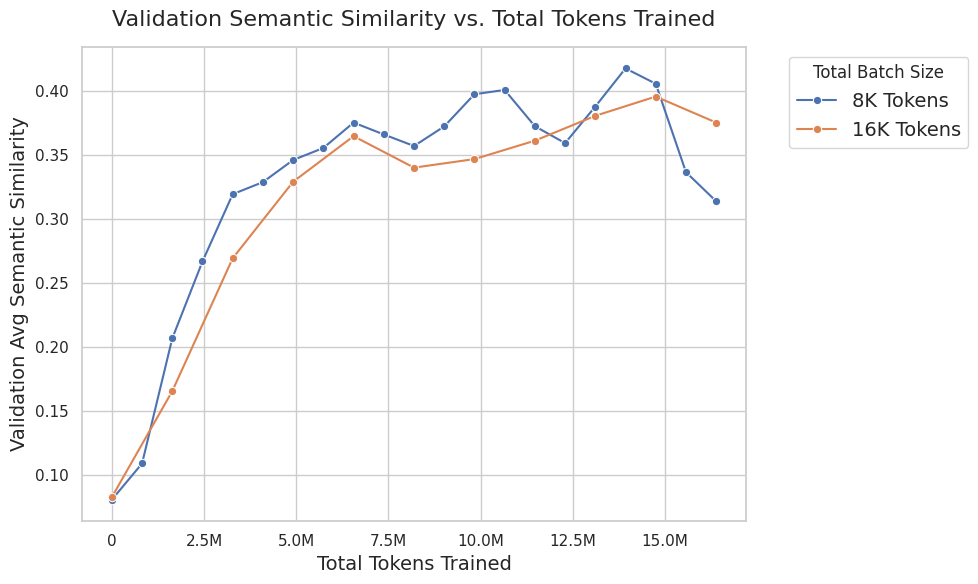

In [4]:
import wandb
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Setup API and Parameters
api = wandb.Api()
project_path = "as7629-columbia-university/Multimodal-Nanochat"

# The exact names of your runs in W&B
target_run_names = [
    "iteration2000_totalBS8192_lr1e-2",
    "iteration1000_totalBS16384_lr1e-2",
    "iteration500_totalBS32768_lr1e-2"
]

# Dictionary to map run names to their respective total batch sizes
batch_size_mapping = {
    "iteration2000_totalBS8192_lr1e-2": 8192,
    "iteration1000_totalBS16384_lr1e-2": 16384,
    "iteration500_totalBS32768_lr1e-2": 32768
}

# Dictionary to map run names to clean, custom labels for the graph legend
custom_labels = {
    "iteration2000_totalBS8192_lr1e-2": "8K Tokens",
    "iteration1000_totalBS16384_lr1e-2": "16K Tokens",
    "iteration500_totalBS32768_lr1e-2": "32K Tokens"
}

target_metric = "val/avg_semantic_similarity"
val_data = []

# 2. Extract Validation Data from W&B
for name in target_run_names:
    runs = api.runs(project_path, filters={"display_name": name})
    
    if len(runs) == 0:
        print(f"Warning: No run found with name '{name}'")
        continue
        
    run = runs[0]
    print(f"Fetching '{target_metric}' for run: {name}")
    
    # Scan history and only grab rows where the validation metric exists
    for row in run.scan_history():
        if target_metric in row and row[target_metric] is not None:
            val_data.append({
                "Run Name": name,
                "step": row.get("step", row.get("_step")),
                target_metric: row[target_metric]
            })

# 3. Process the DataFrame
val_df = pd.DataFrame(val_data)

if not val_df.empty:
    # Map batch size and calculate the aligned x-axis (samples_seen)
    val_df["batch_size"] = val_df["Run Name"].map(batch_size_mapping)
    val_df["samples_seen"] = val_df["step"] * val_df["batch_size"]
    
    # Apply the custom labels to a new column for the legend
    val_df["Configuration"] = val_df["Run Name"].map(custom_labels)
    
    # 4. Plot the Validation Metric
    sns.set_theme(style="whitegrid")
    plt.figure(figsize=(10, 6))
    
    # Plot using our new 'samples_seen' x-axis and 'Configuration' hue
    sns.lineplot(
        data=val_df, 
        x="samples_seen", 
        y=target_metric, 
        hue="Configuration", 
        linewidth=1.5,
        marker="o",      
        markersize=6
    )
    
    # Formatting titles and labels
    plt.title("Validation Semantic Similarity vs. Total Tokens Trained", fontsize=16, pad=15)
    plt.xlabel("Total Tokens Trained", fontsize=14)
    plt.ylabel("Validation Avg Semantic Similarity", fontsize=14)
    
    # Prevent scientific notation on the x-axis (e.g., 1.6e7)
    plt.ticklabel_format(style='plain', axis='x')
    from matplotlib.ticker import FuncFormatter
    def human_readable(x, pos):
        if x >= 1e6:
            return f"{x/1e6:.1f}M"
        elif x >= 1e3:
            return f"{x/1e3:.1f}K"
        else:
            return str(int(x))
    ax = plt.gca()
    ax.xaxis.set_major_formatter(FuncFormatter(human_readable))
    
    # Position the legend outside the plot area
    plt.legend(title="Total Batch Size", bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=14)
    plt.tight_layout()
    
    # Save the figure and display it
    plt.savefig("val_semantic_similarity_comparison.png", dpi=300)
    print("\nPlot saved successfully as 'val_semantic_similarity_comparison.png'")
    plt.show()
else:
    print(f"\nDataFrame is empty! Make sure '{target_metric}' was logged exactly like that in W&B.")

In [6]:
val_df

,Run Name,step,val/avg_semantic_similarity,batch_size,samples_seen,Configuration
0,iteration2000_totalBS8192_lr1e-2,0,0.080955,8192,0,8K Tokens
1,iteration2000_totalBS8192_lr1e-2,100,0.109187,8192,819200,8K Tokens
2,iteration2000_totalBS8192_lr1e-2,200,0.206755,8192,1638400,8K Tokens
3,iteration2000_totalBS8192_lr1e-2,300,0.266781,8192,2457600,8K Tokens
4,iteration2000_totalBS8192_lr1e-2,400,0.319223,8192,3276800,8K Tokens
5,iteration2000_totalBS8192_lr1e-2,500,0.328665,8192,4096000,8K Tokens
6,iteration2000_totalBS8192_lr1e-2,600,0.345897,8192,4915200,8K Tokens
7,iteration2000_totalBS8192_lr1e-2,700,0.355268,8192,5734400,8K Tokens
8,iteration2000_totalBS8192_lr1e-2,800,0.375073,8192,6553600,8K Tokens
9,iteration2000_totalBS8192_lr1e-2,900,0.365830,8192,7372800,8K Tokens


# Tune Evaluation Batch Size

In [38]:
import wandb
import pandas as pd

# 1. Initialize API and set parameters
api = wandb.Api()
project_path = "as7629-columbia-university/Multimodal-Nanochat"

# Replace these with the actual names of the runs you want to compare
target_run_names = [
    "baseline_evalBS1_KVCacheFalse", 
    "evalBS8_KVCacheFalse",
    "optimized_evalBS16_KVCacheFalse", # this run should have been trained for 500 iterations. Since loss and validation scores plateau, this did not affect analysis.
    "evalBS32_KVCacheFalse",
    "evalBS64_KVCacheFalse"
] 

# Define which summary metrics you want to pull down
metrics_to_compare = [
    "val/tok_per_sec",
    "val/avg_generation_time_seconds"
]

data = []

# 2. Fetch and extract data for each run
for name in target_run_names:
    runs = api.runs(project_path, filters={"display_name": name})
    
    if len(runs) == 0:
        print(f"Warning: No run found with name '{name}'")
        continue
        
    run = runs[0]
    
    # Build a dictionary of the run's metadata
    run_data = {
        "Run Name": run.name,
        "Run ID": run.id,
        "State": run.state
    }
    
    # --- NEW: Extract Configuration Parameters ---
    # We use .get() just like we do with summary metrics to prevent crashes 
    # if the config key is missing in an older run
    run_data["eval_batch_size"] = run.config.get("eval_batch_size", None)
    
    
    # Extract the summary metrics
    for metric in metrics_to_compare:
        run_data[metric] = run.summary.get(metric, None)
        
    data.append(run_data)

# 3. Create a DataFrame for clean visualization
df = pd.DataFrame(data)


# Print the final comparison table
print("--- Run Comparison ---")
print(df.to_string(index=False))

--- Run Comparison ---
                       Run Name   Run ID    State  eval_batch_size  val/tok_per_sec  val/avg_generation_time_seconds
  baseline_evalBS1_KVCacheFalse tg5j2ne4 finished                1        34.308440                         3.730860
           evalBS8_KVCacheFalse pxd154ot finished                8       175.430114                         0.694721
optimized_evalBS16_KVCacheFalse d0kw5c9k finished               16       197.084300                         0.649468
          evalBS32_KVCacheFalse ka0j8whr finished               32       195.786089                         0.653775
          evalBS64_KVCacheFalse 9toiphyv finished               64       174.014276                         0.735572


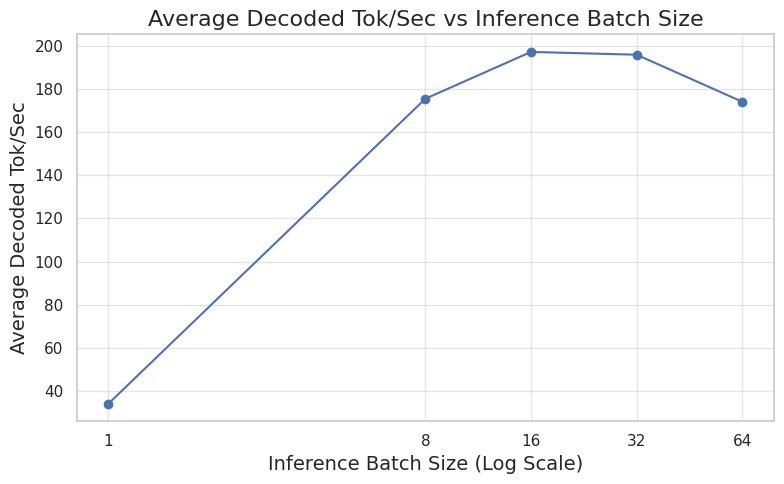

In [40]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))

# Plot the lines
plt.plot(df['eval_batch_size'], df['val/tok_per_sec'], marker='o', label='Tokens per Second')

# Set the x-axis to log scale (base 2 is most intuitive for batch sizes)
plt.xscale('log', base=2)

# Explicitly set the ticks to match your data points
ticks = [1, 8, 16, 32, 64]
plt.xticks(ticks, labels=[str(t) for t in ticks])

# Add labels and legend
plt.title('Average Decoded Tok/Sec vs Inference Batch Size',fontsize=16)
plt.xlabel('Inference Batch Size (Log Scale)', fontsize=14)
plt.ylabel('Average Decoded Tok/Sec', fontsize=14)

plt.grid(True, which="both", ls="-", alpha=0.5) # Adding a grid helps see the log spacing
plt.tight_layout()
plt.show()